## Check the two-poing correlation function

In [53]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import lsstypes as types

os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

sys.path.insert(0, '../../')
from cat_tools import get_measurement_fn
from fit_tools import read_data_from_fn
from helper import GET_REDSHIFT_SET


[000701.32]  05-21 04:29  TwoPointEstimator            INFO     Loading /pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/QSO/mock0/mpspk/mpslog_QSO_z0.8-2.1_NGC_DR2_v2.0.npy.


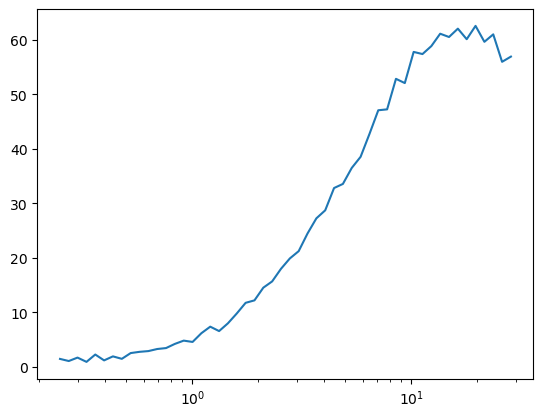

In [28]:
corr = 'mpslog' # xi, pk, mpslog, wplog, mesh2

data_args = dict(
    version = 'AbacusHF-v2',
    tracer = 'QSO',
    region = 'NGC',
    domain = 'altmtl',
    zrange = (0.8, 2.1),
    mockid = 0,
)

fn = get_measurement_fn(**data_args, use_jax=False)
(s,tps),_ = read_data_from_fn(fn, corr)
plt.plot(s, s**2*tps[0], label='mpslog')
plt.xscale('log')

[008102.19]  06-02 02:55  TwoPointEstimator            INFO     Loading /pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/Boxes/QSO/sn1p550/AbacusSummit_base_c000_ph000/mpspk/mpslog_QSO_zp1.550_DR2_v2.0.npy.
[008102.20]  06-02 02:55  TwoPointEstimator            INFO     Loading /global/cfs/cdirs/desi/users/arocher/Y3/loa-v1/v1.1/PIP/cosmo_0/smu/allcounts_QSO_GCcomb_0.8_2.1_pip_angular_bitwise_log_njack128_nran4_split20.npy.
[008103.31]  06-02 02:55  TwoPointEstimator            INFO     Loading /global/cfs/cdirs/desi/users/arocher/Y3/loa-v1/v1.1/PIP/cosmo_0/smu/allcounts_QSO_GCcomb_1.4_1.7_pip_angular_bitwise_log_njack128_nran4_split20.npy.
[008104.56]  06-02 02:55  TwoPointEstimator            INFO     Loading /pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/Boxes/QSO/sn1p550/AbacusSummit_base_c000_ph000/mpspk/mpslog_QSO_zp1.550_DR2_v2.0.npy.
[008104.63]  06-02 02:55  TwoPointEstimator            INFO     Loading /global/cfs/cdirs/desi/users/arocher/Y3/loa-v1/v1.1/PIP/co

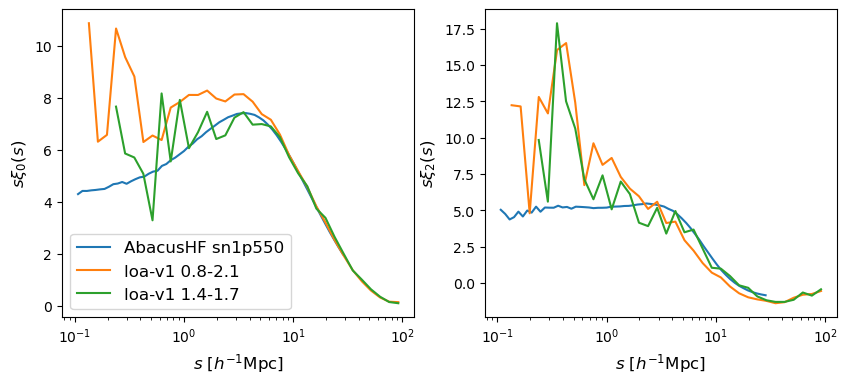

In [85]:
from pycorr import TwoPointCorrelationFunction, project_to_multipoles, project_to_wp

fig = plt.figure(figsize=(10,4))

for ill in [0,1]:
    ax = fig.add_subplot(1,2,ill+1)
    fn1 = '/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/Boxes/QSO/sn1p550/AbacusSummit_base_c000_ph000/mpspk/mpslog_QSO_zp1.550_DR2_v2.0.npy'
    (s, tps), _ = read_data_from_fn(fn, 'mpslog')
    plt.plot(s, s*tps[ill], label = 'AbacusHF sn1p550')

    fn2 = '/global/cfs/cdirs/desi/users/arocher/Y3/loa-v1/v1.1/PIP/cosmo_0/smu/allcounts_QSO_GCcomb_0.8_2.1_pip_angular_bitwise_log_njack128_nran4_split20.npy'
    result = TwoPointCorrelationFunction.load(fn2)
    result = project_to_multipoles(result, ells=(0,2))
    s = result[0]
    xi = result[1]
    plt.plot(s, s*xi[ill], label = 'loa-v1 0.8-2.1')

    fn3 = '/global/cfs/cdirs/desi/users/arocher/Y3/loa-v1/v1.1/PIP/cosmo_0/smu/allcounts_QSO_GCcomb_1.4_1.7_pip_angular_bitwise_log_njack128_nran4_split20.npy'
    result = TwoPointCorrelationFunction.load(fn3)
    result = project_to_multipoles(result, ells=(0,2))
    s = result[0]
    xi= result[1]
    plt.plot(s, s*xi[ill], label = 'loa-v1 1.4-1.7')
    plt.xscale('log')
    if ill == 0:
        plt.legend(fontsize=12)
    plt.ylabel(rf'$s \xi_{ill*2}(s)$', fontsize=12)
    plt.xlabel(r'$s$ [$h^{-1}$Mpc]', fontsize=12)

In [62]:
result[1]

array([[            nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,  8.05158877e+01,  3.86880914e+01,
         3.32902302e+01,  4.45720673e+01,  3.29540310e+01,
         2.50592051e+01,  1.47954255e+01,  1.26942398e+01,
         1.01997988e+01,  1.00664847e+01,  8.54246463e+00,
         7.29303064e+00,  6.02038486e+00,  5.07183181e+00,
         4.03158502e+00,  3.28115143e+00,  2.79991199e+00,
         2.31501808e+00,  1.84286743e+00,  1.42855289e+00,
         1.14454368e+00,  8.69308731e-01,  6.32033370e-01,
         4.65601921e-01,  3.39379322e-01,  2.34591008e-01,
         1.62126379e-01,  1.05825203e-01,  6.66242624e-02,
         3.90448864e-02,  2.21886493e-02,  1.14660038e-02,
         5.20265064e-03,  2.15744234e-03,  1.59197080e-03],
       [            nan,             nan,             n

In [45]:
result[:1]
result[:2]


[array([           nan,            nan, 1.56666775e-02, 2.14217390e-02,
        2.54034274e-02, 3.03874527e-02, 3.46682209e-02, 4.25817015e-02,
        5.25349480e-02, 6.25551652e-02, 7.65335179e-02, 9.28658258e-02,
        1.10910294e-01, 1.35020441e-01, 1.63244176e-01, 1.97601354e-01,
        2.39350491e-01, 2.90260119e-01, 3.52101145e-01, 4.25987871e-01,
        5.16215301e-01, 6.25468646e-01, 7.57745347e-01, 9.18024401e-01,
        1.11254368e+00, 1.34756643e+00, 1.63287124e+00, 1.97829098e+00,
        2.39663241e+00, 2.90354853e+00, 3.51785008e+00, 4.26193116e+00,
        5.16343639e+00, 6.25548409e+00, 7.57883945e+00, 9.18200861e+00,
        1.11242581e+01, 1.34772763e+01, 1.63281142e+01, 1.97817723e+01,
        2.39659238e+01, 2.90352638e+01, 3.51767557e+01, 4.26172396e+01,
        5.16312907e+01, 6.25518456e+01, 7.57819016e+01, 9.18097535e+01]),
 array([[            nan,             nan,             nan,
                     nan,             nan,             nan,
              